In [1]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../../../'))
sys.path.insert(0, src_dir)
import src
# plt.style.use('../../../foresight.mplstyle')


/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from jax.lib import xla_bridge
import jax
print(xla_bridge.get_backend().platform)
name = "cuDNN"
jax._src.lib.cuda_versions.cudnn_get_version()
# jax._src.lib.cuda_versions.cudnn_build_version()
jax.default_device = jax.devices("gpu")[0]

gpu


Predict 4500 steps: :   0%|          | 1/4500 [00:00<10:07,  7.41it/s]

Predict 4500 steps: : 100%|██████████| 4500/4500 [00:00<00:00, 9450.57it/s] 


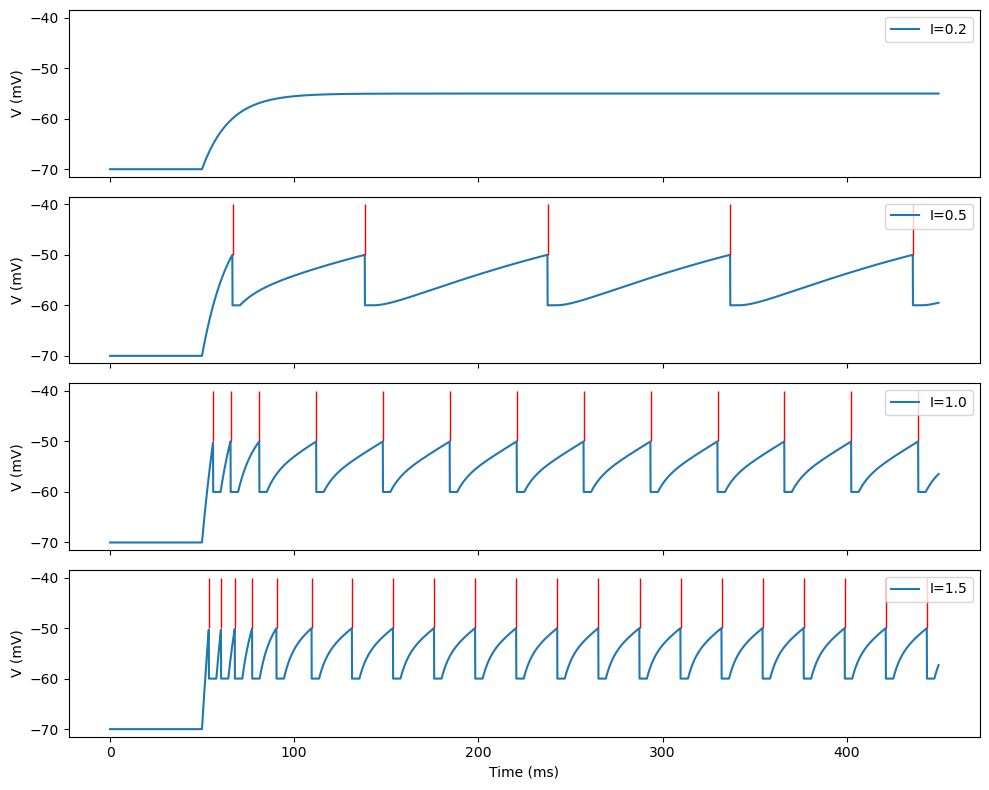

In [3]:
duration = 1000  # Simulation duration in ms
Is = [0.25, 0.5, 1., 1.5]

fig, axes = plt.subplots(len(Is), 1, figsize=(10, 8), sharex=True, sharey=True)

for i, I in enumerate(Is):
    neuron = src.neurons.FNSNeuron(
        size=1,
        C=0.25,
        g_L=0.0167,
        V_L=-70.0,
        V_th=-50.0,
        V_rt=-60.0,
        tau_ref=4.0,
        tau_K=80.0,
        V_initializer=bp.init.Constant(-70.0),
    )

    runner = bp.DSRunner(neuron, monitors=['V', 'input', 'spike'])
    inputs = bp.inputs.section_input([[0.], [I]], [50., 400.], dt=runner.dt)
    runner.run(inputs=inputs)

    axes[i].plot(runner.mon['ts'], runner.mon['V'], label='I=%.1f' % I)
    spikes = np.where(runner.mon['spike'])[0]
    spike_times = runner.mon['ts'][spikes]
    axes[i].vlines(spike_times, neuron.V_th, neuron.V_th+10, color='r', linewidth=1)

    axes[i].set_ylabel('V (mV)')
    axes[i].legend()

axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()


Array(value=Array([[ True]]), dtype=bool)


Predict 2000 steps: :   0%|          | 0/2000 [00:00<?, ?it/s]

Predict 2000 steps: : 100%|██████████| 2000/2000 [00:03<00:00, 523.30it/s] 


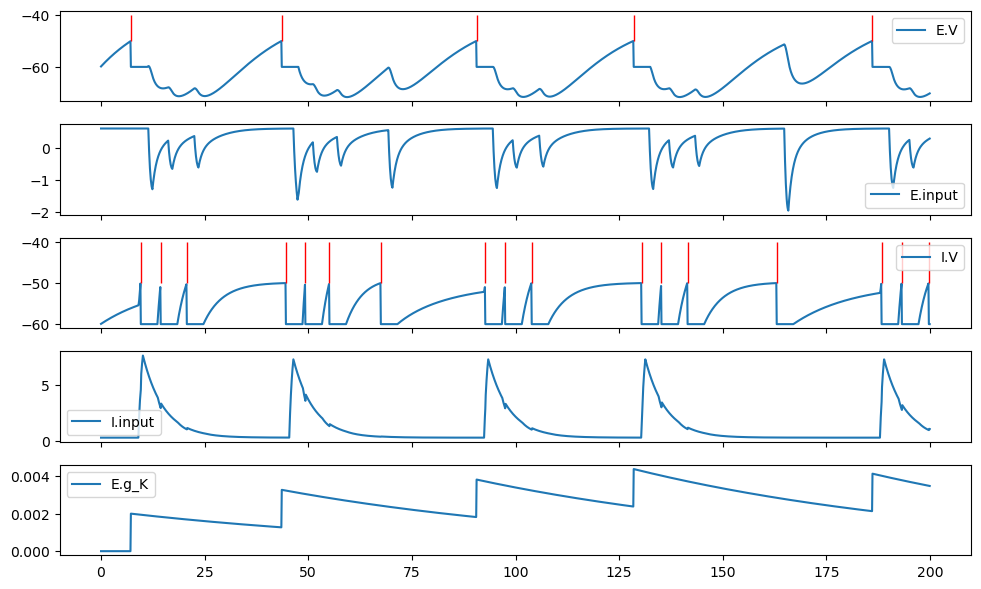

In [4]:
# * Couple one excitatory and one inhibitory neuron and check dynamics look ok
class TwoCellCircuit(bp.Network):
    def __init__(self):
        super().__init__()
        self.E = src.neurons.FNSNeuron(
            size=1,
            C=0.25,
            g_L=0.0167,
            V_L=-70.0,
            V_th=-50.0,
            V_rt=-60.0,
            tau_ref=4.0,
            tau_K=80.0,
            Delta_g_K = 0.002,
            V_initializer=bp.init.Constant(-60.0),
        )
        self.I = src.neurons.FNSNeuron(
            size=1,
            C=0.25,
            g_L=0.0167,
            V_L=-70.0,
            V_th=-50.0,
            V_rt=-60.0,
            tau_ref=4.0,
            tau_K=80.0,
            Delta_g_K = 0.00,
            V_initializer=bp.init.Constant(-60.0),
        )
        g = 0.2

        self.E2I = src.synapses.Synapse(
            pre=self.E, post=self.I, conn=bp.connect.FixedProb(prob=1.0), delay = 2.0,
            g_max=g,
            V_rev=0.0,
            tau_r = 1.0,
            tau_d = 5.0,
        )
        self.I2E = src.synapses.Synapse(
            pre=self.I, post=self.E, conn=bp.connect.FixedProb(prob=1.0), delay = 2.0, g_max=g,
            V_rev=-80.0,
            tau_r = 1.0,
            tau_d = 3.0,
        )
        self.Ein = bp.dyn.InputVar(self.E.varshape)
        self.Iin = bp.dyn.InputVar(self.I.varshape)
        self.E.add_inp_fun("", self.Ein)
        self.I.add_inp_fun("", self.Iin)

circuit = TwoCellCircuit()
print(circuit.E2I.proj.comm.conn.build_mat())
runner = bp.DSRunner(circuit, monitors=['E.V', 'E.spike', 'E.input', 'I.V', 'I.spike', 'I.input', 'E.g_K'], inputs=[('Ein.input', 0.6), ('Iin.input', 0.335)])
runner.run(200)

fig, axes = plt.subplots(5, 1, figsize=(10, 6), sharex=True)

axes[0].plot(runner.mon['ts'], runner.mon['E.V'], label='E.V')
spikes = np.where(runner.mon['E.spike'])[0]
spike_times = runner.mon['ts'][spikes]
axes[0].vlines(spike_times, neuron.V_th, neuron.V_th+10, color='r', linewidth=1)

axes[1].plot(runner.mon['ts'], runner.mon['E.input'], label='E.input')

axes[2].plot(runner.mon['ts'], runner.mon['I.V'], label='I.V')
spikes = np.where(runner.mon['I.spike'])[0]
spike_times = runner.mon['ts'][spikes]
axes[2].vlines(spike_times, neuron.V_th, neuron.V_th+10, color='r', linewidth=1)

axes[3].plot(runner.mon['ts'], runner.mon['I.input'], label='I.input')

axes[4].plot(runner.mon['ts'], runner.mon['E.g_K'], label='E.g_K')

[axes[i].legend() for i in range(len(axes))]
plt.tight_layout()
plt.show()


In [5]:
from src.models.FNS import FNScircuit
rho = 100
sigma_ee = 0.1
FNSnet = FNScircuit(rho=rho, sigma_ee=sigma_ee)

/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/brainpy/_src/dyn/others/input.py:212: UserWarning: 
  warnings.warn('')


In [6]:
FNSnet.to_dict()


{'FNScircuit': {'parameters': {'rho': 100,
   'dx': 1.0,
   'sigma_ee': 0.1,
   'sigma_ei': 0.1,
   'sigma_ie': 0.1,
   'sigma_ii': 0.125,
   'p_ee': 0.1,
   'p_ei': 0.2,
   'p_ie': 0.3,
   'p_ii': 0.3,
   'boundary': 'periodic',
   'include_self': True,
   'gamma': 4,
   'nu': 1,
   'J_e': 0.0004,
   'method': 'exp_auto'},
  'populations': {'E': {'size': (10, 10),
    'C': 0.25,
    'g_L': 0.0167,
    'V_L': -70.0,
    'V_K': -85.0,
    'V_th': -50.0,
    'V_rt': -60.0,
    'tau_ref': 4.0,
    'tau_K': 80.0,
    'Delta_g_K': 0.002,
    'embedding': {'GridPositions': {'domain': (1.0, 1.0)}},
    '_V_initializer': {'Uniform': {'min_val': -70.0, 'max_val': -50.0}},
    '_g_K_initializer': 'ZeroInit'},
   'I': {'size': (25,),
    'C': 0.25,
    'g_L': 0.0167,
    'V_L': -70.0,
    'V_K': -85.0,
    'V_th': -50.0,
    'V_rt': -60.0,
    'tau_ref': 4.0,
    'tau_K': 80.0,
    'Delta_g_K': 0.0,
    'embedding': {'RandomPositions': {'domain': (1.0, 1.0)}},
    '_V_initializer': {'Uniform': {'

/var/tmp/pbs.15450.headnode/ipykernel_999679/2100056350.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


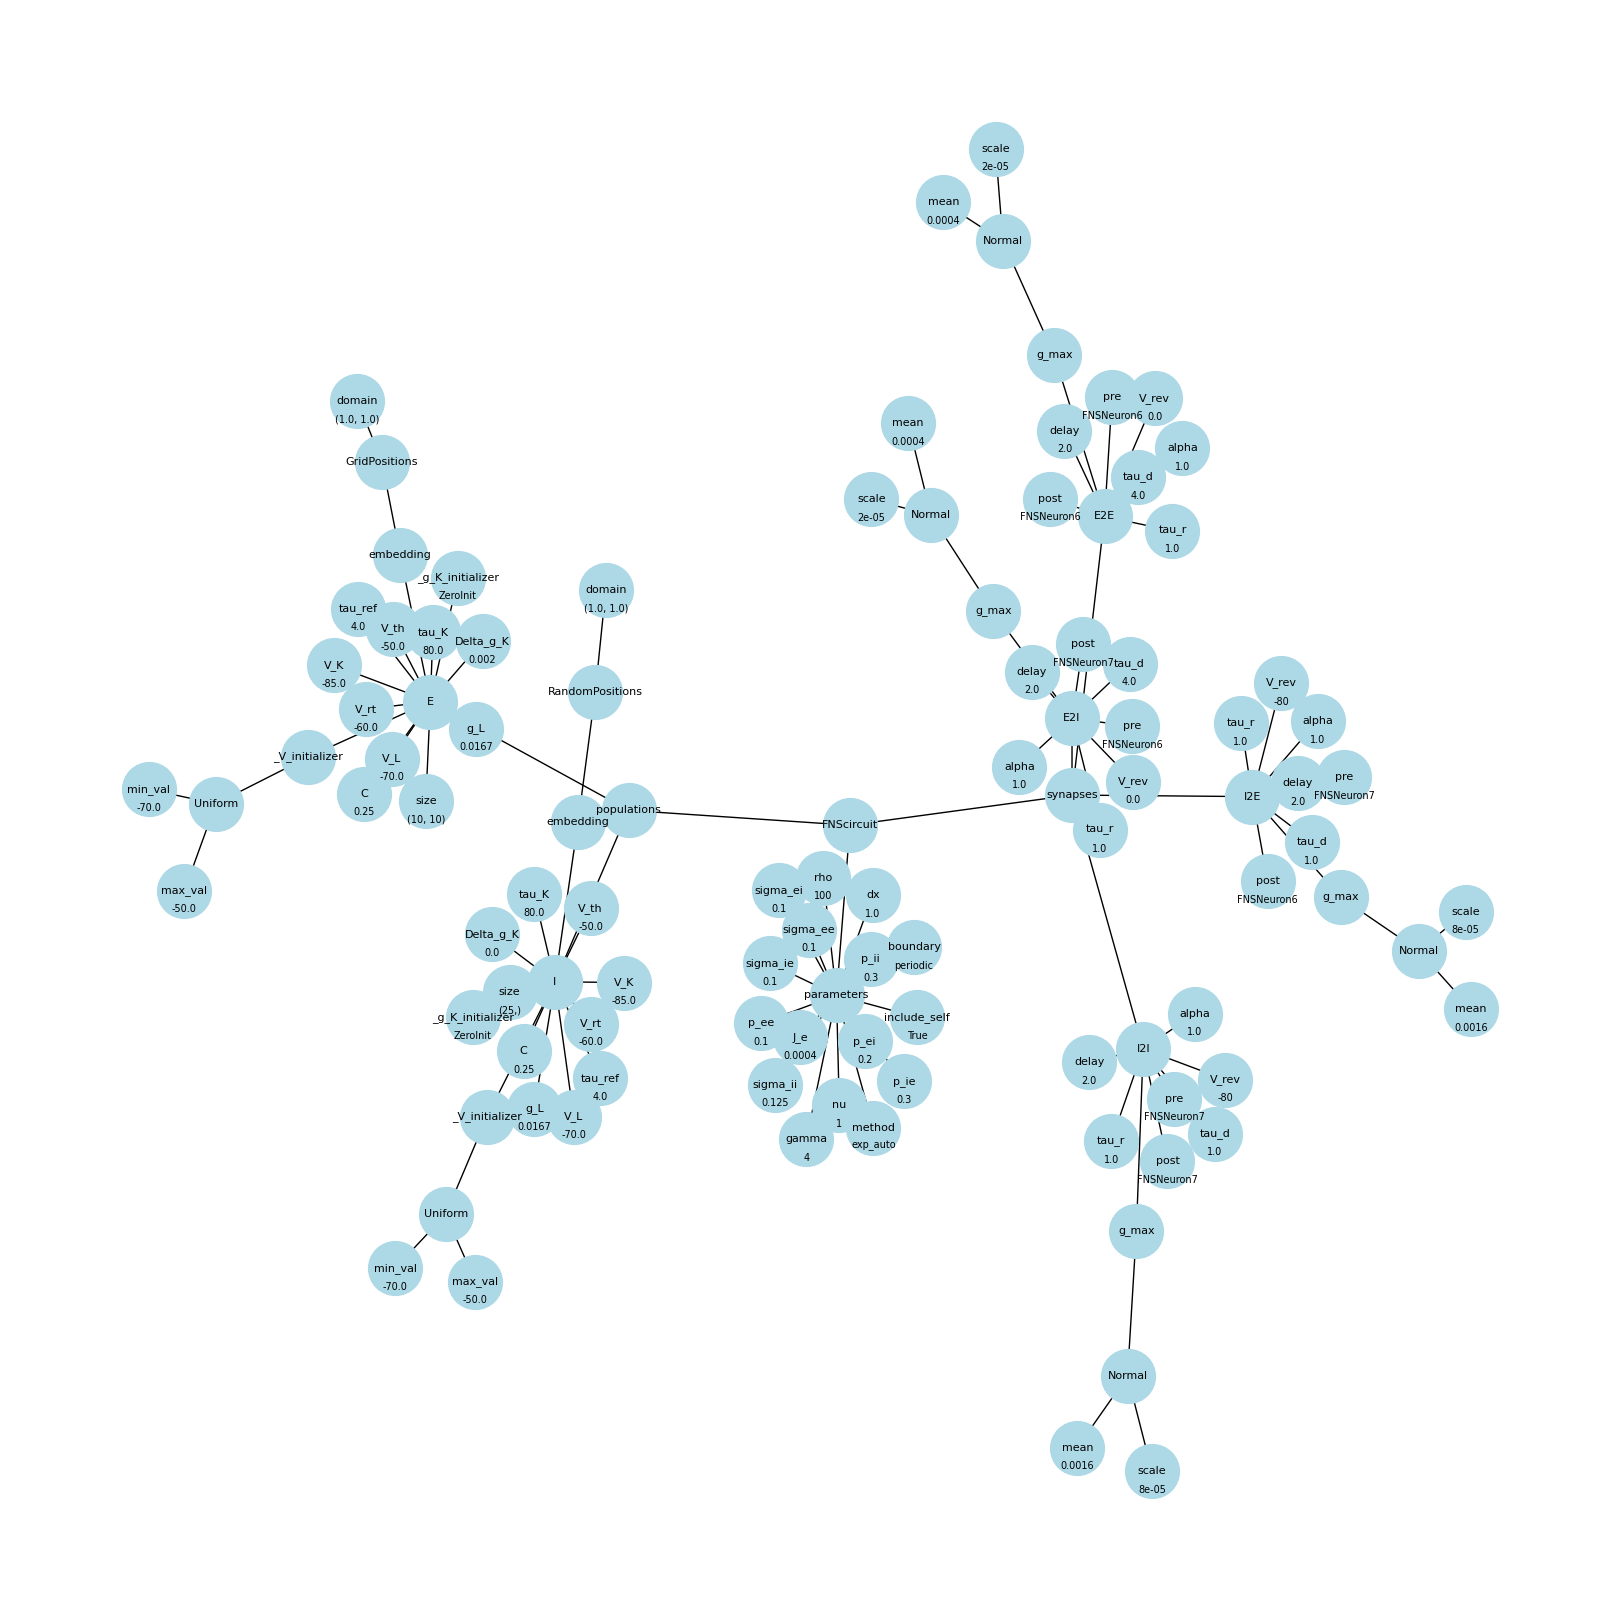

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# Initialize a directed graph
G = nx.DiGraph()

# Global node counter for unique node IDs
node_counter = 0

def add_nodes_edges(d, G, parent=None):
    """
    Recursively adds nodes and edges to the graph based on the dictionary structure.
    """
    global node_counter
    for key, value in d.items():
        node_id = node_counter
        node_counter += 1
        G.add_node(node_id, label=key)  # Add node with key as label

        if parent is not None:
            G.add_edge(parent, node_id)  # Add edge from parent to current node

        if isinstance(value, dict):
            # If value is a dictionary, recurse
            add_nodes_edges(value, G, parent=node_id)
        else:
            # If value is a leaf node, store the value in node attributes
            G.nodes[node_id]['value'] = value

# Build the graph starting from the root
add_nodes_edges(FNSnet.to_dict(), G)

# Create a mapping of node IDs to labels
labels = {node: G.nodes[node]['label'] for node in G.nodes()}

# Try to use a hierarchical layout; fall back to spring layout if not available
# try:
pos = nx.nx_pydot.graphviz_layout(G, prog="sfdp", root=0)
# except:
# pos = nx.spring_layout(G)

# Draw the nodes and edges
plt.figure(figsize=(16, 16))
nx.draw(G, pos, with_labels=False, arrows=False, node_size=1500, node_color='lightblue')

# Draw node labels (keys)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

# Annotate leaf nodes with their values
for node in G.nodes():
    if 'value' in G.nodes[node]:
        x, y = pos[node]
        value = G.nodes[node]['value']
        # Adjust the position to place the value adjacent to the node
        plt.text(x, y-10, s=str(value), fontsize=7, ha='center', va='center', bbox=dict(facecolor='green', alpha=0.0))

# Display the graph
plt.tight_layout()
plt.show()

In [8]:
FNSnet.I2E.proj.comm.conn.require("csr") # No error

(Array([20, 21, 22, 41, 43, 30, 40, 49,  8, 77, 78, 85, 86, 88, 42, 73, 14,
        95, 44, 54, 55, 27, 98, 43, 44,  8, 96, 74, 84, 89, 99, 86, 13, 96,
        15, 74, 84, 92, 23, 90, 96, 99, 32, 40, 56, 82, 93], dtype=int32),
 Array([ 0,  4,  5,  8, 11, 14, 16, 18, 21, 23, 23, 25, 26, 27, 29, 31, 32,
        34, 35, 35, 38, 39, 42, 44, 45, 47], dtype=int32))

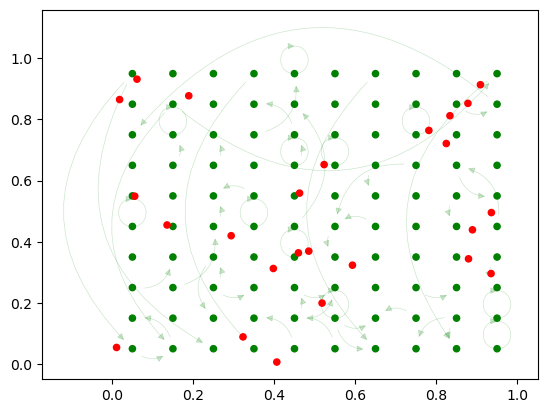

In [9]:
if np.product(FNSnet.E.size) <= 100:
    fig, ax = plt.subplots()
    NE = np.prod(FNSnet.E.size)
    NI = np.prod(FNSnet.I.size)
    E2E = bp.connect.csr2mat((FNSnet.E2E.proj.comm.indices, FNSnet.E2E.proj.comm.indptr), NE, NE)
    I2E = bp.connect.csr2mat((FNSnet.I2E.proj.comm.indices, FNSnet.I2E.proj.comm.indptr), NI, NE)
    E2I = bp.connect.csr2mat((FNSnet.E2I.proj.comm.indices, FNSnet.E2I.proj.comm.indptr), NE, NI)
    I2I = bp.connect.csr2mat((FNSnet.I2I.proj.comm.indices, FNSnet.I2I.proj.comm.indptr), NI, NI)
    fullconn = np.block([
        [E2E, E2I],  # Top row: E->E and E->I
        [I2E, I2I]   # Bottom row: I->E and I->I
    ])
    positions = np.concatenate((FNSnet.E.positions, FNSnet.I.positions))

    num_E = len(FNSnet.E.positions)
    num_I = len(FNSnet.I.positions)
    node_colors = ['g'] * num_E + ['r'] * num_I

    G = nx.from_numpy_array(fullconn, create_using=nx.DiGraph())

    nx.draw_networkx_nodes(
        G,
        pos=positions,
        node_color=node_colors,
        node_size=20,
        ax=ax
    )

    # Get the indices of edges
    sources, targets = np.nonzero(fullconn)

    # Determine if source and target nodes are E or I
    node_types = np.array(['g'] * num_E + ['r'] * num_I)
    source_types = node_types[sources]
    target_types = node_types[targets]

    # Set edge colors based on node types
    edge_colors = np.full(len(sources), 'nothing')  # Default color for between-population edges
    edge_colors[(source_types == 'g') & (target_types == 'g')] = 'g'  # E->E edges
    edge_colors[(source_types == 'r') & (target_types == 'r')] = 'r'  # I->I edges
    idxs = (source_types == 'g') & (target_types == 'g') # Only show E->E eges?
    # Draw all edges at once with their respective colors
    nx.draw_networkx_edges(
        G,
        pos=positions,
        edgelist=np.array(list(zip(sources, targets)))[idxs],
        connectionstyle="arc3,rad=0.5",
        edge_color=np.array(edge_colors)[idxs],
        width=0.5,
        alpha=0.2,
        ax=ax
    )
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)



In [10]:
# Optimize construction
size = (50, 50)
conn = src.models.FNS.DistanceDependent(  # This part seems slow... can we fix? or jax?
            src.models.FNS.GaussianKernel(
                sigma=0.125, p_max=0.5,
            ),
            (1, 1),
            src.positions.GridPositions((1, 1))(size),
            boundary="periodic",
            include_self=False,
        )
plt.imshow(conn.require(size, size, "conn_mat"))

ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: traced array with shape int32[].
It arose in the jnp.arange argument 'start'
The error occurred while tracing the function process_chunk_inner at /headnode2/bhar9988/code/DDC/Dewdrop.jl/src/models/FNS.py:285 for jit. This concrete value was not available in Python because it depends on the value of the argument start.

See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.ConcretizationTypeError

/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/brainpy/_src/dyn/others/input.py:212: UserWarning: 
  warnings.warn('')


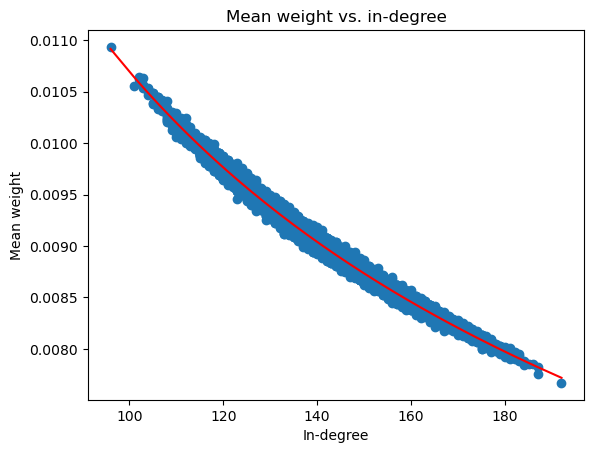

140.96481
141.3716694115407


Predict 20000 steps: : 100%|██████████| 20000/20000 [00:13<00:00, 1518.38it/s]


ValueError: The weights and list don't have the same length.

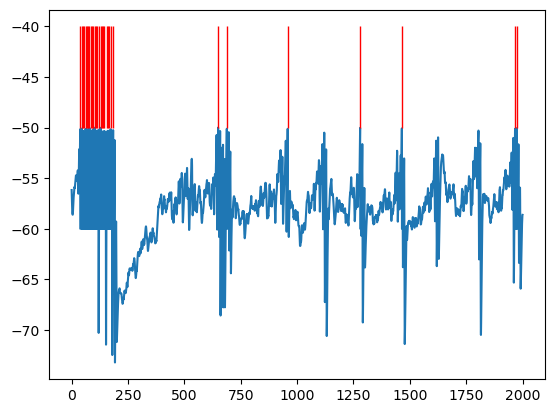

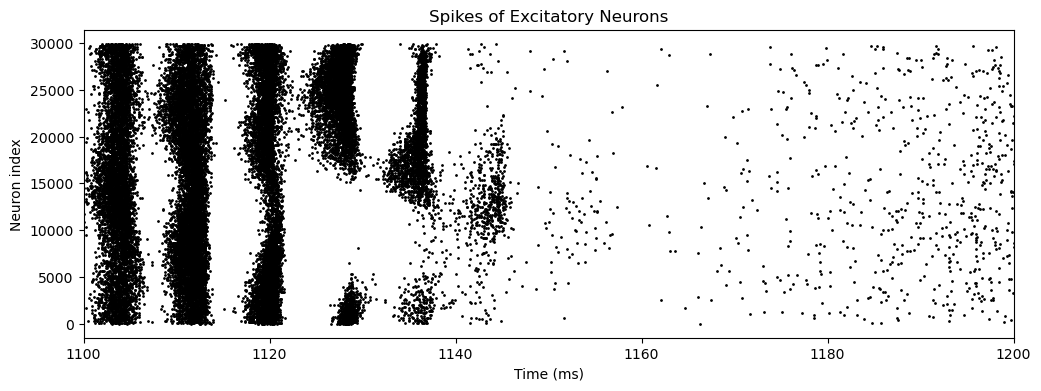

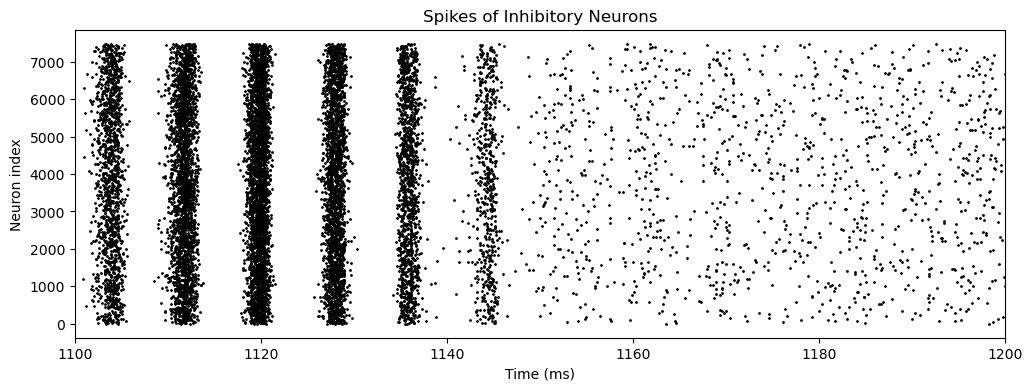

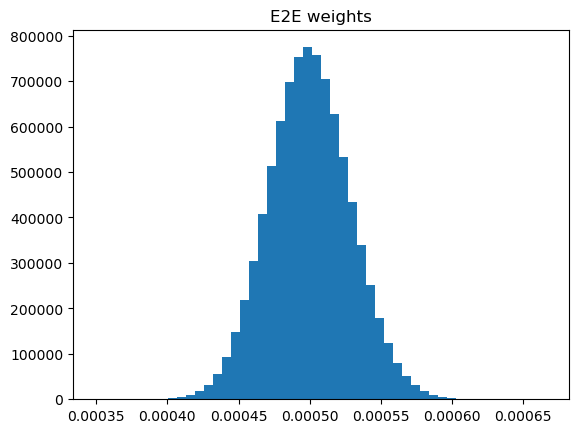

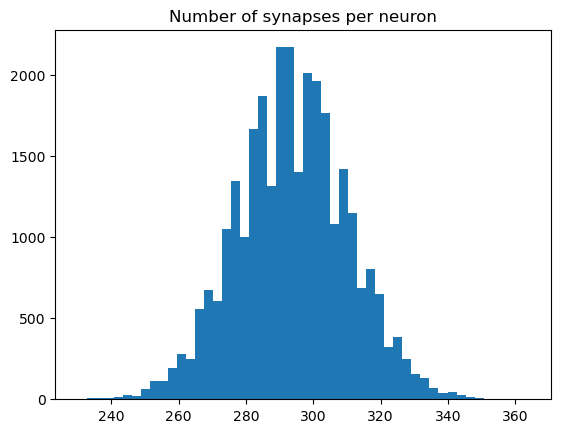

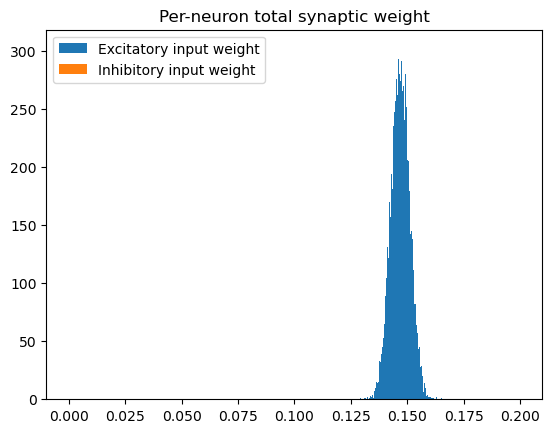

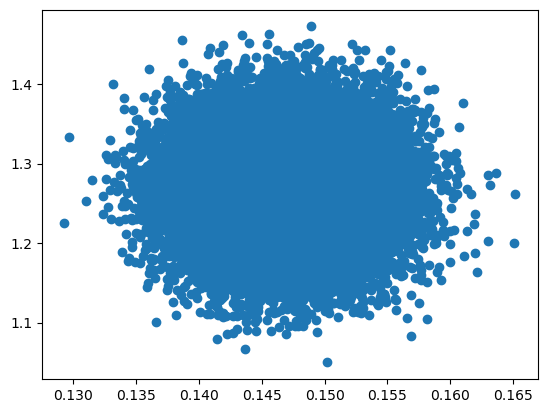

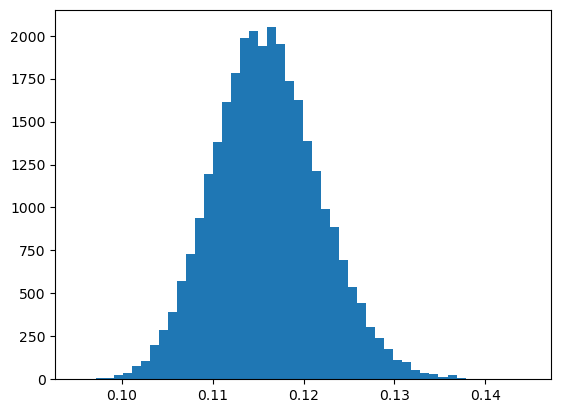

In [ ]:
# plt.imshow(runner.mon['E.V'].view(),aspect='auto')

In [ ]:
# * Test connection probabilities

rho = 10000 # Around 1 minute for rho = 30000
sigma_ee = 0.05
p_max = 0.5
FNSnet = FNScircuit(rho=rho, sigma_ee=sigma_ee, p_ee=p_max)

/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/brainpy/_src/dyn/others/input.py:212: UserWarning: 
  warnings.warn('')


In [ ]:
# * Find the distribution of distances for connected E2E neurons using the E2E connectivity
E2E = FNSnet.E2E.proj.comm.conn.require("coo") # coo returns row-column indices
@jax.jit
def compute_distances(E2E, pos_array, domain):
    row, col = E2E
    p1 = pos_array[row]
    p2 = pos_array[col]
    dx = (p2[:, 0] - p1[:, 0] + domain[0] / 2) % domain[0] - domain[0] / 2
    dy = (p2[:, 1] - p1[:, 1] + domain[1] / 2) % domain[1] - domain[1] / 2
    return jnp.sqrt(dx * dx + dy * dy)

distances = compute_distances(E2E, jnp.array(FNSnet.E.positions), FNSnet.E.embedding.domain)

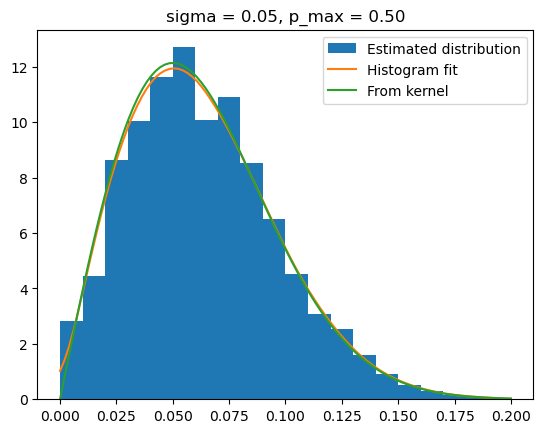

In [ ]:
rmax = 0.2
ds = distances[distances < rmax]

plt.hist(ds, bins=20, density=True, label='Estimated distribution')

import scipy
kde = scipy.stats.gaussian_kde(ds, bw_method=0.2)
xx = np.linspace(0, rmax, 100)
plt.plot(xx, kde(xx), label="Histogram fit")

# plt.kde_plot(ds)
# plt.set_xlabel("Distance")
# # plt.set_ylabel("Density")
plt.gca().set_title("sigma = %.2f, p_max = %.2f" % (FNSnet.E2E.proj.comm.conn.kernel.sigma, FNSnet.E2E.proj.comm.conn.kernel.p_max))
# * plot the kernel,
kernel = FNSnet.E2E.proj.comm.conn.kernel
area_measure = lambda x: 2*np.pi*x # Accounts for the fact that we are in a 2D space and the number of point pairs grows with r
real_kernel = lambda x: area_measure(x)*kernel(x)
xs = np.linspace(0, rmax, 100)
dx = xs[1] - xs[0]
plt.plot(xs, real_kernel(xs)/(dx*np.sum(real_kernel(xs))), label='From kernel')
plt.legend()
# ! Then add a fit evaluation
plt.show()

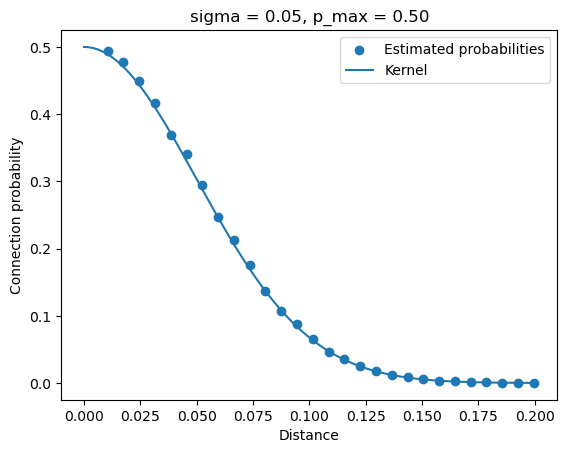

In [ ]:
# * Slightly different q.: what is the connection probability as a function of distance?
E2E = FNSnet.E2E.proj.comm.conn.require("coo") # coo returns row-column indices
@jax.jit
def compute_probabilities(E2E, pos_array, domain, num_bins=100):
    # ---------------------------------------------------------------------
    # 1) Create adjacency matrix A from E2E = (row_indices, col_indices).
    #    A[i,j] = 1 if there's a connection from i to j, else 0.
    # ---------------------------------------------------------------------
    N = pos_array.shape[0]
    row_idx, col_idx = E2E

    # For large N, watch out for memory usage. But for demonstration:
    A = jnp.zeros((N, N), dtype=jnp.float32).at[row_idx, col_idx].set(1.0)

    # If undirected, typically you'd also want A[j, i] = 1.0, but that depends on your data.

    # ---------------------------------------------------------------------
    # 2) Compute the full NxN distance matrix with periodic boundary conditions.
    # ---------------------------------------------------------------------
    i_grid, j_grid = jnp.indices((N, N))
    px = pos_array[:, 0]
    py = pos_array[:, 1]

    dx = (px[j_grid] - px[i_grid] + domain[0]/2) % domain[0] - domain[0]/2
    dy = (py[j_grid] - py[i_grid] + domain[1]/2) % domain[1] - domain[1]/2
    dist_matrix = jnp.sqrt(dx*dx + dy*dy)

    # ---------------------------------------------------------------------
    # 3) Mask out i >= j if you only want i < j (no double-counting)
    #    JAX won't let us do dist_matrix[mask], so we use jnp.where.
    # ---------------------------------------------------------------------
    # upper_mask[i,j] = True if i<j else False
    # We'll keep distances for i<j, otherwise set them to -1
    upper_mask = (i_grid < j_grid)

    # Flatten everything to 1D
    dist_flat    = dist_matrix.ravel()  # shape (N*N,)
    A_flat       = A.ravel()            # adjacency weights
    mask_flat    = upper_mask.ravel()   # shape (N*N,)

    # We'll do a "masked" version of distances:
    # For pairs that we want to skip, set distance to -1.0.
    dist_masked = jnp.where(mask_flat, dist_flat, -1.0)

    # Similarly for adjacency (0 if we skip).
    A_masked    = jnp.where(mask_flat, A_flat, 0.0)

    # ---------------------------------------------------------------------
    # 4) Histogram the distances from 0..max_dist. -1.0 is out of range => not counted.
    # ---------------------------------------------------------------------
    max_dist = dist_matrix.max()  # largest distance in the entire NxN matrix
    bins = jnp.linspace(max_dist/(num_bins+1), max_dist, num_bins+1)

    # We'll do "counts_total" by weighting every valid pair with 1.0,
    # and "counts_conn" by weighting every valid pair with A_masked
    # so that edges get counted, non-edges don't.
    ones_masked = jnp.where(mask_flat, 1.0, 0.0)

    # dist_masked.shape => (N*N,) => need shape (N*N,1) for histogramdd
    sample_for_hist = dist_masked[:, None]  # shape (N*N, 1)

    counts_total, bin_edges = jnp.histogramdd(
        sample_for_hist,
        bins=[bins],
        weights=ones_masked,
    )
    counts_conn, bin_edges = jnp.histogramdd(
        sample_for_hist,
        bins=[bins],
        weights=A_masked,
    )

    # ---------------------------------------------------------------------
    # 5) Probability = (#connected) / (#total)
    #    Handle empty bins with 0 instead of NaN.
    # ---------------------------------------------------------------------
    p_bin = jnp.where(counts_total > 0, counts_conn / counts_total, 0.0)

    bin_centers = 0.5 * (bin_edges[0][:-1] + bin_edges[0][1:])

    return bin_centers, p_bin

distances, probabilities = compute_probabilities(E2E, jnp.array(FNSnet.E.positions), FNSnet.E.embedding.domain)

rmax = 0.2
idxs = distances < 0.2
plt.scatter(distances[idxs], probabilities[idxs], label='Estimated probabilities')
kernel = FNSnet.E2E.proj.comm.conn.kernel
xs = np.linspace(0, rmax, 100)
dx = xs[1] - xs[0]
plt.plot(xs, kernel(xs), label='Kernel')
plt.gca().set_title("sigma = %.2f, p_max = %.2f" % (kernel.sigma, kernel.p_max))
plt.gca().set_xlabel("Distance")
plt.gca().set_ylabel("Connection probability")
plt.legend()
